Name = Arav Mahind

Roll = 24102A2008

Branch-Div = CMPN-A

Assingment 01

Practical: Air-Quality Data Cleaning Using R
Topic
Loops, Functions, Error Handling, and Advanced Missing Data Handling
Subtopic
Management of NA, NULL, and NaN Values

In [65]:
# ============================
# Task 1: Import Dataset with Error Handling
# ============================

air_data <- tryCatch({

  read.csv(
    "PRSA_Data_Aotizhongxin_20130301-20170228.csv",
    stringsAsFactors = FALSE
  )

}, error = function(e) {

  cat("Error while reading the dataset:\n")
  cat(e$message, "\n")

  return(NULL)
})

if (!is.null(air_data)) {
  cat("Dataset imported successfully!\n")
}

Dataset imported successfully!


In [66]:
# ============================
# Task 1: Inspect Dataset
# ============================

cat("First 6 Records:\n")
head(air_data)

cat("\nStructure of Dataset:\n")
str(air_data)

cat("\nRows :", nrow(air_data), "\n")
cat("Columns :", ncol(air_data), "\n")

cat("\nContains Missing Values :", any(is.na(air_data)), "\n")
cat("Total Missing Values :", sum(is.na(air_data)), "\n")

First 6 Records:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>
1,1,2013,3,1,0,4,4,4,7,300,77,-0.7,1023.0,-18.8,0,NNW,4.4,Aotizhongxin
2,2,2013,3,1,1,8,8,4,7,300,77,-1.1,1023.2,-18.2,0,N,4.7,Aotizhongxin
3,3,2013,3,1,2,7,7,5,10,300,73,-1.1,1023.5,-18.2,0,NNW,5.6,Aotizhongxin
4,4,2013,3,1,3,6,6,11,11,300,72,-1.4,1024.5,-19.4,0,NW,3.1,Aotizhongxin
5,5,2013,3,1,4,3,3,12,12,300,72,-2.0,1025.2,-19.5,0,N,2.0,Aotizhongxin
6,6,2013,3,1,5,5,5,18,18,400,66,-2.2,1025.6,-19.6,0,N,3.7,Aotizhongxin



Structure of Dataset:
'data.frame':	35064 obs. of  18 variables:
 $ No     : int  1 2 3 4 5 6 7 8 9 10 ...
 $ year   : int  2013 2013 2013 2013 2013 2013 2013 2013 2013 2013 ...
 $ month  : int  3 3 3 3 3 3 3 3 3 3 ...
 $ day    : int  1 1 1 1 1 1 1 1 1 1 ...
 $ hour   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ PM2.5  : num  4 8 7 6 3 5 3 3 3 3 ...
 $ PM10   : num  4 8 7 6 3 5 3 6 6 8 ...
 $ SO2    : num  4 4 5 11 12 18 18 19 16 12 ...
 $ NO2    : num  7 7 10 11 12 18 32 41 43 28 ...
 $ CO     : int  300 300 300 300 300 400 500 500 500 400 ...
 $ O3     : num  77 77 73 72 72 66 50 43 45 59 ...
 $ TEMP   : num  -0.7 -1.1 -1.1 -1.4 -2 -2.2 -2.6 -1.6 0.1 1.2 ...
 $ PRES   : num  1023 1023 1024 1024 1025 ...
 $ DEWP   : num  -18.8 -18.2 -18.2 -19.4 -19.5 -19.6 -19.1 -19.1 -19.2 -19.3 ...
 $ RAIN   : num  0 0 0 0 0 0 0 0 0 0 ...
 $ wd     : chr  "NNW" "N" "NNW" "NW" ...
 $ WSPM   : num  4.4 4.7 5.6 3.1 2 3.7 2.5 3.8 4.1 2.6 ...
 $ station: chr  "Aotizhongxin" "Aotizhongxin" "Aotizhongxin" "Aotizhon

In [67]:
# ============================
# Task 2: NA, NULL and NaN
# ============================

# Check missing values (NA) in the imported dataset
cat("Missing values in each column:\n")
print(colSums(is.na(air_data)))

# NULL example
null_value <- NULL
cat("\nNULL Example:\n")
print(null_value)
cat("is.null(NULL):", is.null(null_value), "\n")

# NaN example
nan_value <- 0/0
cat("\nNaN Example:\n")
print(nan_value)
cat("is.nan(NaN):", is.nan(nan_value), "\n")

Missing values in each column:
     No    year   month     day    hour   PM2.5    PM10     SO2     NO2      CO 
      0       0       0       0       0     925     718     935    1023    1776 
     O3    TEMP    PRES    DEWP    RAIN      wd    WSPM station 
   1719      20      20      20      20      81      14       0 

NULL Example:
NULL
is.null(NULL): TRUE 

NaN Example:
[1] NaN
is.nan(NaN): TRUE 


In [68]:
# ============================
# Task 3: Missing Summary Function
# ============================

missing_summary <- function(data) {

  # Variables mentioned in the assignment
  variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

  # Keep only variables that exist in the dataset
  variables <- variables[variables %in% names(data)]

  # Missing values count
  missing_count <- colSums(is.na(data[variables]))

  # Missing percentage
  missing_percentage <- round(
    (missing_count / nrow(data)) * 100,
    2
  )

  # Create summary table
  summary_table <- data.frame(
    Variable = variables,
    Missing_Values = missing_count,
    Missing_Percentage = missing_percentage
  )

  print(summary_table)

  # Warning if missing percentage > 20%
  for(i in 1:nrow(summary_table)){

    if(summary_table$Missing_Percentage[i] > 20){

      warning(
        paste(
          summary_table$Variable[i],
          "has more than 20% missing values."
        )
      )

    }

  }

  return(summary_table)
}

# Apply function
missing_report <- missing_summary(air_data)

      Variable Missing_Values Missing_Percentage
PM2.5    PM2.5            925               2.64
PM10      PM10            718               2.05
SO2        SO2            935               2.67
NO2        NO2           1023               2.92
TEMP      TEMP             20               0.06
WSPM      WSPM             14               0.04
wd          wd             81               0.23


In [69]:
# ============================
# Task 4: Create pollution_ratio
# ============================

# Create pollution_ratio
air_data$pollution_ratio <- air_data$PM2.5 / air_data$PM10

# Count invalid values
cat("NA values :", sum(is.na(air_data$pollution_ratio)), "\n")
cat("NaN values:", sum(is.nan(air_data$pollution_ratio)), "\n")
cat("Infinite values:", sum(is.infinite(air_data$pollution_ratio)), "\n")

# Replace NaN and Infinite values with NA
air_data$pollution_ratio[
  is.nan(air_data$pollution_ratio) |
  is.infinite(air_data$pollution_ratio)
] <- NA

cat("\nInvalid values (NaN & Infinite) replaced with NA.\n")

# Display first 10 records
head(air_data[, c("PM2.5", "PM10", "pollution_ratio")], 10)

NA values : 934 
NaN values: 0 
Infinite values: 0 

Invalid values (NaN & Infinite) replaced with NA.


,PM2.5,PM10,pollution_ratio
,<dbl>,<dbl>,<dbl>
1,4,4,1.000
2,8,8,1.000
3,7,7,1.000
4,6,6,1.000
5,3,3,1.000
6,5,5,1.000
7,3,3,1.000
8,3,6,0.500
9,3,6,0.500


In [70]:
# ============================
# Task 5: Handle Missing Numerical Values
# ============================

# Numerical variables given in the assignment
numeric_variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM")

# Save missing values before cleaning
before_cleaning <- colSums(is.na(air_data[numeric_variables]))

# Loop through each variable
for (var in numeric_variables) {

  # Check whether the column exists
  if (var %in% names(air_data)) {

    # Missing values before replacement
    missing_before <- sum(is.na(air_data[[var]]))

    # Calculate median
    median_value <- median(air_data[[var]], na.rm = TRUE)

    # Replace missing values with median
    air_data[[var]][is.na(air_data[[var]])] <- median_value

    # Missing values after replacement
    missing_after <- sum(is.na(air_data[[var]]))

    # Display details
    cat("\n----------------------------\n")
    cat("Variable :", var, "\n")
    cat("Missing Before :", missing_before, "\n")
    cat("Median Used :", median_value, "\n")
    cat("Missing After :", missing_after, "\n")

  } else {

    cat("\nColumn", var, "does not exist.\n")

  }
}


----------------------------
Variable : PM2.5 
Missing Before : 925 
Median Used : 58 
Missing After : 0 

----------------------------
Variable : PM10 
Missing Before : 718 
Median Used : 87 
Missing After : 0 

----------------------------
Variable : SO2 
Missing Before : 935 
Median Used : 9 
Missing After : 0 

----------------------------
Variable : NO2 
Missing Before : 1023 
Median Used : 53 
Missing After : 0 

----------------------------
Variable : TEMP 
Missing Before : 20 
Median Used : 14.5 
Missing After : 0 

----------------------------
Variable : WSPM 
Missing Before : 14 
Median Used : 1.4 
Missing After : 0 


In [71]:
# ============================
# Task 6: Handle Missing Categorical Values
# ============================

# Function to calculate mode
calculate_mode <- function(x) {

  x <- x[!is.na(x)]   # Remove NA values

  unique_values <- unique(x)

  unique_values[which.max(tabulate(match(x, unique_values)))]
}

# Missing values before replacement
wd_missing_before <- sum(is.na(air_data$wd))

# Calculate mode
wd_mode <- calculate_mode(air_data$wd)

# Replace missing values with mode
air_data$wd[is.na(air_data$wd)] <- wd_mode

# Missing values after replacement
wd_missing_after <- sum(is.na(air_data$wd))

# Display results
cat("Mode of wd:", wd_mode, "\n")
cat("Missing Before:", wd_missing_before, "\n")
cat("Missing After :", wd_missing_after, "\n")

Mode of wd: NE 
Missing Before: 81 
Missing After : 0 


In [72]:
# ============================
# Task 7: clean_variable() with tryCatch()
# ============================

clean_variable <- function(data, variable_name) {

  tryCatch({

    # Check if variable exists
    if (!(variable_name %in% names(data))) {
      stop("Variable does not exist in the dataset.")
    }

    # Check if variable is numeric
    if (!is.numeric(data[[variable_name]])) {
      stop("Variable is categorical. Median cannot be calculated.")
    }

    # Check if all values are NA
    if (all(is.na(data[[variable_name]]))) {
      stop("All values are NA.")
    }

    # Calculate median
    median_value <- median(data[[variable_name]], na.rm = TRUE)

    # Replace missing values
    data[[variable_name]][is.na(data[[variable_name]])] <- median_value

    cat(variable_name, "cleaned successfully.\n")
    cat("Median Used:", median_value, "\n\n")

    return(data)

  }, error = function(e) {

    cat("Error:", e$message, "\n")
    return(data)

  })

}

# Apply the function to one numerical variable
air_data <- clean_variable(air_data, "PM2.5")

PM2.5 cleaned successfully.
Median Used: 58 



In [73]:
# ============================
# Task 8: Comparison Table
# ============================

# Variables specified in the assignment
variables <- c("PM2.5", "PM10", "SO2", "NO2", "TEMP", "WSPM", "wd")

# Missing values after cleaning
after_cleaning <- sapply(variables, function(var) {
  sum(is.na(air_data[[var]]))
})

# Missing values before cleaning
before_values <- c(
  before_cleaning,
  wd_missing_before
)

# Missing values after cleaning
after_values <- c(
  after_cleaning[1:6],
  wd_missing_after
)

# Create comparison table
comparison_table <- data.frame(
  Variable = variables,
  Missing_Before = before_values,
  Missing_After = after_values,
  Values_Replaced = before_values - after_values
)

print(comparison_table)

      Variable Missing_Before Missing_After Values_Replaced
PM2.5    PM2.5            925             0             925
PM10      PM10            718             0             718
SO2        SO2            935             0             935
NO2        NO2           1023             0            1023
TEMP      TEMP             20             0              20
WSPM      WSPM             14             0              14
            wd             81             0              81


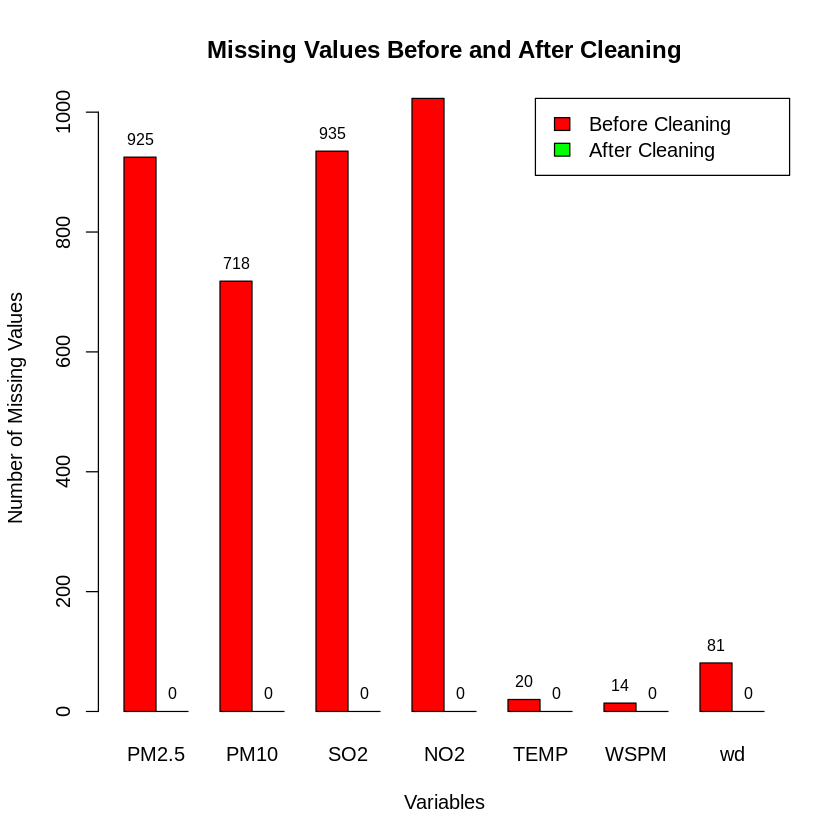

In [76]:
bar_positions <- barplot(
  missing_matrix,
  beside = TRUE,
  col = c("red", "green"),
  names.arg = variables,
  main = "Missing Values Before and After Cleaning",
  xlab = "Variables",
  ylab = "Number of Missing Values",
  legend.text = c("Before Cleaning", "After Cleaning"),
  args.legend = list(x = "topright")
)

text(
  x = bar_positions,
  y = missing_matrix,
  labels = missing_matrix,
  pos = 3,
  cex = 0.8
)

In [77]:
print(comparison_table)

      Variable Missing_Before Missing_After Values_Replaced
PM2.5    PM2.5            925             0             925
PM10      PM10            718             0             718
SO2        SO2            935             0             935
NO2        NO2           1023             0            1023
TEMP      TEMP             20             0              20
WSPM      WSPM             14             0              14
            wd             81             0              81


In [75]:
# ============================
# Task 10: Export Cleaned Dataset
# ============================

write.csv(
  air_data,
  "cleaned_air_quality_data.csv",
  row.names = FALSE
)

cat("Cleaned dataset exported successfully as 'cleaned_air_quality_data.csv'\n")

Cleaned dataset exported successfully as 'cleaned_air_quality_data.csv'


Conclusion:
In this assignment, the air quality dataset was successfully imported, analyzed, and cleaned using R. Missing values were identified and handled using appropriate techniques for numerical and categorical data. A new variable was created, error handling was implemented, and the cleaned dataset was exported for future use. This assignment improved my understanding of data preprocessing, functions, loops, and exception handling in R.